<a href="https://colab.research.google.com/github/sesabe10/Ciencia-de-datos/blob/main/Laboratorio1_Incremento1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
---
# 📚 MÓDULO B — Fundamentos Conceptuales
### Bodegas de Datos · Modelos Multidimensionales · Estadística · Histogramas · Outliers · Missings
---


## ⚙️ Configuración inicial

In [22]:
import pandas as pd

# ── Carga del dataset (ajusta la ruta según tu ambiente) ─────────────
ruta = "/content/drive/MyDrive/SEMINARIO DE LA CIENCIA DE LOS DATOS/Laboratorios/Laboratorio Incremento/dataset_banco - dataset_banco.csv"
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
except:
    pass

try:
    data = pd.read_csv(ruta)
    data.columns = data.columns.str.lower().str.strip()
    for col in data.select_dtypes('object').columns:
        data[col] = data[col].str.lower().str.strip()
    data.dropna(inplace=True)
    data.drop_duplicates(inplace=True)
    print(f"✅ Dataset bancario cargado: {data.shape[0]:,} filas × {data.shape[1]} columnas")
except Exception as e:
    print(f"❌ Error al cargar el dataset: {e}")

data.head(3)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Dataset bancario cargado: 45,203 filas × 17 columnas


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143.00,yes,no,unknown,5,may,261.00,1,-1.00,0,unknown,no
1,44,technician,single,secondary,no,29.00,yes,no,unknown,5,may,151.00,1,-1.00,0,unknown,no
2,33,entrepreneur,married,secondary,no,2.00,yes,yes,unknown,5,may,76.00,1,-1.00,0,unknown,no


# Resolución de taller

## Preguntas - Nivel descriptivo

### ¿Cuántas observaciones y variables tiene el dataset?

In [19]:
print(f"El dataset contiene {data.shape[0]} observaciones y {data.shape[1]} variables")

El dataset contiene 45203 observaciones y 17 variables


### ¿Qué tipos de variables existen (numéricas / categóricas)?

In [15]:
categoricas = data.select_dtypes(include=['object']).columns.tolist()
numericas = data.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f"Las variables categóricas son: {categoricas}")
print(f"Las variables numéricas son: {numericas}")

Las variables categóricas son: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']
Las variables numéricas son: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


### ¿Cuál crees que es la variable más importante y por qué?
- Y: es la variable más importante porque representa el resultado de la campaña, puede considerar variable objetivo.

In [ ]:
data.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

### ¿Qué variables parecen tener escalas muy diferentes?

#### Balance y Duration  tiene valores muy altos lo que puede indicar gran dispersión de los datos

In [ ]:
data.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45203.00,45203.00,45203.00,45203.00,45203.00,45203.00,45203.00
mean,41.01,1373.89,15.81,258.04,2.76,40.18,0.58
std,12.04,3923.85,8.32,257.47,3.10,100.10,2.30
min,18.00,-8019.00,1.00,-1389.00,1.00,-1.00,0.00
25%,33.00,72.00,8.00,103.00,1.00,-1.00,0.00
50%,39.00,448.00,16.00,180.00,2.00,-1.00,0.00
75%,48.00,1427.50,21.00,319.00,3.00,-1.00,0.00
max,776.00,527532.00,31.00,4918.00,63.00,871.00,275.00


## Preguntas – Nivel crítico

### ¿Qué información no puedes obtener solo con describe()?

#### describe() se centra mas que todo en un resumen estadístico por lo que no me puede ofrecer información de las variables categóricas como la frecuencia de estas o la correlación que puedan tener o detección de outliers

### ¿Por qué describe() no muestra variables categóricas?

#### Porque describe() por defecto solo resume variables numéricas (media, std, etc.).

### ¿Qué variable podría generar problemas si se analiza solo con promedios?

In [ ]:
#Balance tiene outliers  muy extremos lo que altera la media
data.describe().mean().idxmax()

'balance'

## Paso 2: Variable objetivo (sin modelar)

In [ ]:
data['y'].value_counts()
data['y'].value_counts(normalize=True)

conteo = data['y'].value_counts()
porcentaje = round(data['y'].value_counts(normalize=True) * 100, 1)

print("Conteo:")
print(conteo)
print("\nPorcentajes:")
print(porcentaje)

Conteo:
y
no     39916
yes     5287
Name: count, dtype: int64

Porcentajes:
y
no    88.30
yes   11.70
Name: proportion, dtype: float64


## Preguntas – Interpretación

### ¿Cuál es la clase mayoritaria?

#### No: con 39916

### ¿Qué porcentaje representa la clase minoritaria?

#### Representa un 11%

### ¿Este comportamiento es realista en campañas bancarias?

#### Si porque normlamente las tasas de conversión suelen ser muy bajas por factores como desconfianza o requisitos muy extrictos.

### ¿Qué riesgo existe si ignoramos la clase minoritaria?

#### El modelo se sesgaría siempre a la clase 'No' lo que afectaría su precisión

## Preguntas – Pensamiento crítico

### ¿Un dataset balanceado siempre representa mejor la realidad?

#### No. Si bien tener los datos balanceados mejora el aprendizaje del modelo no siempre representa mejor la realidad.

### ¿Qué decisiones del negocio podrían verse afectadas por este desbalance?

- Calcular mal el ROI de la campaña
- Asignar mal el presupuesto de marketing
- Subestimar el valor de ciertos perfiles (ej. jubilados, estudiantes)

### ¿Qué variable podría estar relacionada con la clase “yes”?

#### duration : las llamadas que terminan en "yes" tienden a ser mucho más largas es una de las variables con mayor poder predictivo, ya que un cliente que habla por mas timepo puede estar mas interesado.

### PARTE 2 – CALIDAD DE DATOS

In [ ]:
data.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


### ¿Qué variables tienen valores faltantes?

#### ¿Qué variables tienen valores faltantes?

#### aparentemente ninguno

### ¿Eliminarías filas con NA? ¿Por qué?

#### Si porque no representan un gran pocentaje que afecte el dataset

### ¿Qué información podrías perder?

#### Información de clientes específicos (perfiles demográficos únicos), pero dado el bajo número, es negligible

### ¿Imputarías todos los NA con la misma técnica?

#### No; para numéricas (balance, duration) usaría mediana/media; para categóricas (job, education) modo o "unknown".

### ¿Eliminar NA podría introducir sesgo?
Posiblemente, si los NA están en subgrupos específicos (clientes de bajos ingresos), pero con tan pocos, el riesgo es bajo.

### ¿Qué tipo de clientes podrían quedar fuera del análisis?
Clientes con perfiles incompletos, posiblemente de grupos vulnerables (desempleados si job=NA).

### ¿Esto afectaría la representatividad del dataset?
Minimamente, dado el bajo porcentaje; el dataset seguiría representativo de campañas bancarias.

In [25]:
data.duplicated().sum()

np.int64(0)

### ¿Existen duplicados?
Presuntamente no los hay

### ¿Un duplicado siempre es un error?
No, podría ser coincidencia (clientes con datos idénticos) o entradas válidas repetidas.

### ¿Qué información adicional necesitarías para decidir?
Un ID único de cliente o timestamps para verificar si son errores de ingreso o eventos reales.

### ¿Qué pasaría si eliminamos registros válidos?
Perderíamos datos reales, subestimando frecuencias o afectando el balance de clases.

<Axes: xlabel='balance'>

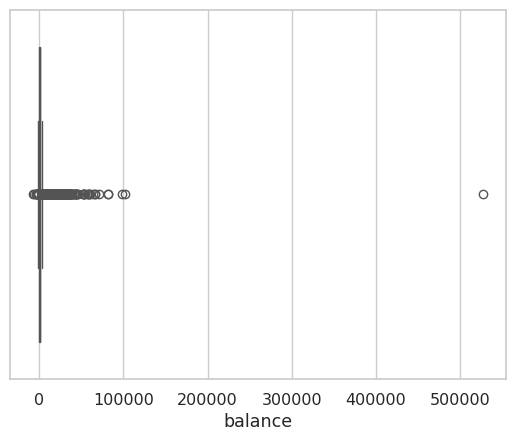

In [26]:
import seaborn as sns
sns.boxplot(x=data['balance'])

### ¿Existen valores extremos?
Hay muchos puntos hacia la derecha lo que indica valores atípicos positivos.

### ¿Son positivos, negativos o ambos?
Ambos: negativos (deudas) y positivos extremos (altos saldos).

### ¿El boxplot te permite ver todos los detalles?
No, solo resume cuartiles y outliers no muestra distribución completa ni multimodalidad.

### ¿Cómo afectan los outliers a la media?
Inflan la media (hacia arriba por positivos extremos), distorsionándola (media 1,374 vs. mediana 448)

### ¿La mediana se ve afectada?
No, la mediana es robusta a outliers.

### ¿Qué estadístico sería más confiable aquí?
La mediana, ya que ignora extremos y representa mejor el centro en distribuciones sesgadas.

### ¿Eliminarías los outliers? Justifica.
No inmediatament primero analizar si son válidos (clientes ricos) usar winsorizing o transformación log.

### ¿Podrían representar clientes reales?
Sí, altos saldos en cuentas premium o deudas en morosos.

### ¿Qué riesgos existen al eliminarlos sin análisis?
Perder segmentos valiosos (clientes high-value), sesgar el modelo hacia casos "normales" y reducir generalización.

### Eje 1 – Datos vs Decisiones
- ¿Qué decisiones de limpieza son más riesgosas?

 - 1. Las decisiones más riesgosas son eliminar outliers o NA sin contexto, ya que podrían sesgar el dataset. Errores como ignorar desbalance podrían llevar a modelos ineficaces en predicción de "yes".
 - ¿Qué errores podrían afectar un modelo futuro?
 - 2. Si eliminamos demasiados datos, el modelo aprende menos.

### Eje 2 – Estadística vs Realidad
- ¿Los outliers siempre son errores?
- 1. Los outliers no siempre son errores podrían ser clientes reales (millonarios) la media no es buena para "balance" por su sensibilidad mediana es mejor.

### Eje 3 – Preparación para el futuro
- ¿Qué información adicional pedirías antes de modelar?
- ¿Qué variable analizarías más a fondo?
- 1. Pediría metadata (fuente de datos, definiciones de variables) y datos adicionales (ingresos). Analizaría "duration" a fondo, ya que correlaciona con conversión.


### Conclusión crítica
El análisis exploratorio muestra que el dataset esta "listo" para ser usado, pero con algunos desafíos comunes. La variable objetivo, “y", está desequilibrada, lo que refleja la realidad en el ámbito bancario. Esto significa que necesitamos utilizar técnicas como la reducción de la muestra mayoritaria para poder modelar los datos de manera efectiva.

Los valores que faltan en el conjunto de datos son mínimos, lo que sugiere que la calidad de los datos es buena en general. Sin embargo, es fundamental imputar cuidadosamente estos valores para evitar sesgos éticos, como excluir perfiles que están subrepresentados.

También hemos encontrado algunos valores atípicos en la variable “balance", lo que podría indicar asimetría en los datos. Esto podría deberse a que hay clientes con valores extremos, por lo que no debemos eliminarlos sin validarlos primero. En su lugar, deberíamos priorizar la mediana sobre la media para resumir los datos.

### Recomendación: ¿Está el dataset listo para modelar? ¿Por qué?
No está completamente listo. Aunque tiene buena estructura y baja tasa de NA/duplicados, requiere limpieza (imputar NA, manejar duplicados/outliers), transformación (encoding categóricas, scaling numéricas) y manejo de desbalance para evitar sesgos en modelos. Tras eso, sería apto.

### Que tipos de Modelos se pueden aplicar al Dataset Bancario?
Dado que es un problema de clasificación binaria (predecir "y": yes/no), se pueden aplicar:

- Modelos de clasificación supervisada: Árboles de decisión, Random Forest, Gradient Boosting (e.g., XGBoost).
- Regresión logística (para interpretabilidad).
- Redes neuronales o SVM para casos complejos.